## Logistic Regression Model

The logistic regression model aims to explore which feature influences income class of a country the most.

In [1]:
# Import libraries
import pandas as pd
import json
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

### 1. Load data used for modelling

In [2]:
# Load JSON file
with open("all_data.json") as f:
    data = json.load(f)

df = pd.DataFrame(data)
display(df)

,Country Name,year,Foreign Investment,GDP per Capita,Unemployment Rate,Labor Force participation rate,v4_prefixes_ris,v6_prefixes_ris,asns_ris,v4_prefixes_stats,v6_prefixes_stats,asns_stats,speed (mgps),bandwidth (kbit/s),Income group,imputed speed,imputed bandwidth,non_imputed_internet_index,imputed_internet_index,Economic Index_y
0,qatar,2022,0.296388,0.345357,0.000806,1.000000,0.008931,0.055823,0.002571,0.382979,0.382979,0.002623,0.352037,0.030656,High income,0.352037,0.030656,0.152325,0.152325,0.520737
1,qatar,2023,0.295860,0.312189,0.000806,0.999550,0.009345,0.068468,0.002371,0.574468,0.574468,0.002769,0.630353,NaN,High income,0.630353,0.068537,NaN,0.241347,0.554932
2,luxembourg,2021,0.346346,0.520874,0.146991,0.529915,0.025711,0.031610,0.015618,0.319149,0.319149,0.017734,0.710388,NaN,High income,0.710388,0.088587,NaN,0.190993,0.470416
3,qatar,2018,0.294219,0.276485,0.000269,0.998703,0.007602,0.002526,0.001653,0.255319,0.255319,0.002178,0.127383,0.012695,High income,0.127383,0.012695,0.083084,0.083084,0.488905
4,qatar,2021,0.295267,0.279262,0.001075,0.978165,0.008310,0.041304,0.002370,0.404255,0.404255,0.002479,0.446277,0.029791,High income,0.446277,0.029791,0.167380,0.167380,0.499364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
645,"Iran, Islamic Rep.",2022,0.296411,NaN,0.241402,0.155980,0.410948,0.030405,0.207912,0.006897,0.006897,0.182334,0.000811,0.065762,None,0.000811,0.065762,0.113996,0.113996,0.028781
649,"Iran, Islamic Rep.",2021,0.296393,NaN,0.246695,0.161691,0.390984,0.029870,0.206519,0.003448,0.003448,0.176897,0.115638,0.134802,None,0.115638,0.134802,0.132701,0.132701,0.027918
650,"Iran, Islamic Rep.",2015,0.296430,NaN,0.297313,0.177869,0.188636,0.000000,0.126721,0.003448,0.003448,0.086683,NaN,0.000000,None,NaN,0.000000,NaN,NaN,0.027524
651,"Iran, Islamic Rep.",2020,0.296390,NaN,0.257577,0.167384,0.338088,0.022330,0.194233,0.000000,0.000000,0.171037,0.107834,0.094407,None,0.107834,0.094407,0.115991,0.115991,0.026305


In [3]:
display(df.head())

,Country Name,year,Foreign Investment,GDP per Capita,Unemployment Rate,Labor Force participation rate,v4_prefixes_ris,v6_prefixes_ris,asns_ris,v4_prefixes_stats,v6_prefixes_stats,asns_stats,speed (mgps),bandwidth (kbit/s),Income group,imputed speed,imputed bandwidth,non_imputed_internet_index,imputed_internet_index,Economic Index_y
0,qatar,2022,0.296388,0.345357,0.000806,1.000000,0.008931,0.055823,0.002571,0.382979,0.382979,0.002623,0.352037,0.030656,High income,0.352037,0.030656,0.152325,0.152325,0.520737
1,qatar,2023,0.295860,0.312189,0.000806,0.999550,0.009345,0.068468,0.002371,0.574468,0.574468,0.002769,0.630353,NaN,High income,0.630353,0.068537,NaN,0.241347,0.554932
2,luxembourg,2021,0.346346,0.520874,0.146991,0.529915,0.025711,0.031610,0.015618,0.319149,0.319149,0.017734,0.710388,NaN,High income,0.710388,0.088587,NaN,0.190993,0.470416
3,qatar,2018,0.294219,0.276485,0.000269,0.998703,0.007602,0.002526,0.001653,0.255319,0.255319,0.002178,0.127383,0.012695,High income,0.127383,0.012695,0.083084,0.083084,0.488905
4,qatar,2021,0.295267,0.279262,0.001075,0.978165,0.008310,0.041304,0.002370,0.404255,0.404255,0.002479,0.446277,0.029791,High income,0.446277,0.029791,0.167380,0.167380,0.499364


In [4]:
# Sort the DataFrame by 'GNI econ indec' in descending order and show the top 5 rows
top_gni = df.sort_values(by="Economic Index_y", ascending=False).head(5)
display(top_gni)

,Country Name,year,Foreign Investment,GDP per Capita,Unemployment Rate,Labor Force participation rate,v4_prefixes_ris,v6_prefixes_ris,asns_ris,v4_prefixes_stats,v6_prefixes_stats,asns_stats,speed (mgps),bandwidth (kbit/s),Income group,imputed speed,imputed bandwidth,non_imputed_internet_index,imputed_internet_index,Economic Index_y
5,qatar,2015,0.297342,0.268474,0.001881,0.994577,0.007642,0.005248,0.001765,0.042553,0.042553,0.001908,NaN,0.008223,High income,0.147355,0.008223,NaN,0.032156,0.557732
1,qatar,2023,0.295860,0.312189,0.000806,0.999550,0.009345,0.068468,0.002371,0.574468,0.574468,0.002769,0.630353,NaN,High income,0.630353,0.068537,NaN,0.241347,0.554932
30,norway,2023,0.306596,0.342329,0.093283,0.597096,0.041138,0.075255,0.053609,0.319149,0.319149,0.057938,0.446360,NaN,High income,0.446360,0.037994,NaN,0.168824,0.553463
23,switzerland,2022,0.285778,0.363077,0.108060,0.622858,0.100960,0.438873,0.148647,0.021277,0.021277,0.162710,0.501059,NaN,High income,0.501059,0.045278,NaN,0.180010,0.523060
10,norway,2022,0.310100,0.423725,0.084121,0.606842,0.040711,0.069841,0.053944,0.297872,0.297872,0.059281,0.410226,NaN,High income,0.410226,0.033838,NaN,0.157948,0.522723


### 2. Select relevant features and develop model

In [5]:
internet_features = [
    "v4_prefixes_ris",
    "v6_prefixes_ris",
    "asns_ris",
    "v6_prefixes_stats",
    "asns_stats",
    "speed (mgps)",
    "bandwidth (kbit/s)",
    "imputed speed",
    "imputed bandwidth",
    "non_imputed_internet_index",
    "imputed_internet_index",
]

In [6]:
df = df.dropna(subset=["Income group"])  # Drop rows without target

le = LabelEncoder()
df["Income group encoded"] = le.fit_transform(df["Income group"])

In [7]:
X = df[internet_features]
X = X.fillna(X.median())

y = df["Income group encoded"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))

                     precision    recall  f1-score   support

        High income       0.76      0.98      0.86       102
         Low income       0.00      0.00      0.00         2
Lower middle income       0.00      0.00      0.00        11
Upper middle income       0.44      0.22      0.29        32

           accuracy                           0.73       147
          macro avg       0.30      0.30      0.29       147
       weighted avg       0.62      0.73      0.66       147



c:\Users\maria\capstone-1\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\maria\capstone-1\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\maria\capstone-1\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [9]:
coefficients = pd.Series(model.coef_[0], index=internet_features).sort_values(
    key=abs, ascending=False
)
print(coefficients)

imputed speed                 2.939334
speed (mgps)                  2.750772
v6_prefixes_ris               1.229436
v6_prefixes_stats            -0.817194
imputed bandwidth             0.709677
asns_ris                      0.689558
asns_stats                    0.684520
imputed_internet_index        0.625121
bandwidth (kbit/s)            0.586851
v4_prefixes_ris               0.382835
non_imputed_internet_index    0.195036
dtype: float64


##### Insights
The model performs strongly on high-income countries but fails to reflect minority classes.Imputed and non-imputed speed have the highest influence on the economic index (target variable) with coefficients of 2.9 and 2.7. 

### Plot model results

In [10]:
# Binarize the output labels (Income groups)
y_test_bin = label_binarize(
    y_test, classes=[0, 1, 2]
)  # Low income: 0, Middle income: 1, High income: 2
y_pred_prob = model.predict_proba(X_test)  # Get predicted probabilities

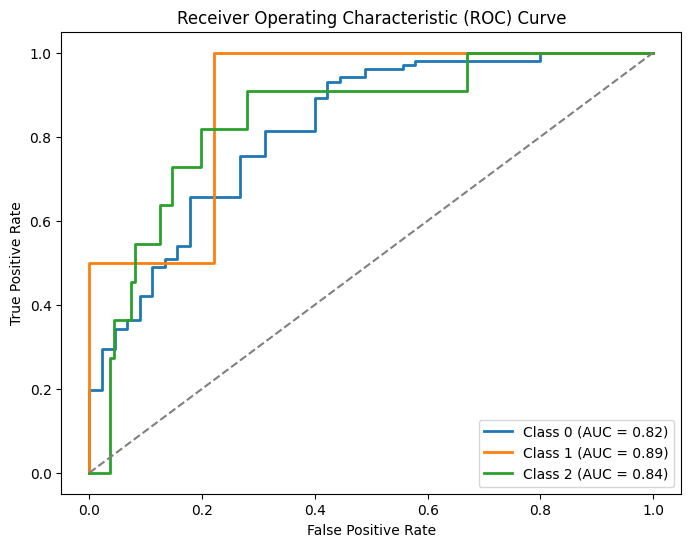

In [11]:
# Initialize plot
plt.figure(figsize=(8, 6))

# Loop over the 3 classes
for i in range(3):  # We have 3 classes (0, 1, 2)
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"Class {i} (AUC = {roc_auc:.2f})")

# Plot the diagonal line (random classifier)
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")

# Label the plot
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()